In [1]:
import json
from pathlib import Path

import numpy as np

from featuregraph_research.utils._arc_agi import get_training_pairs


task_path = Path("../data/arc-agi-2/00576224.json")

with task_path.open(encoding="utf-8") as file:
    task = json.load(file)

training_pairs = get_training_pairs(task)

len(training_pairs)

2

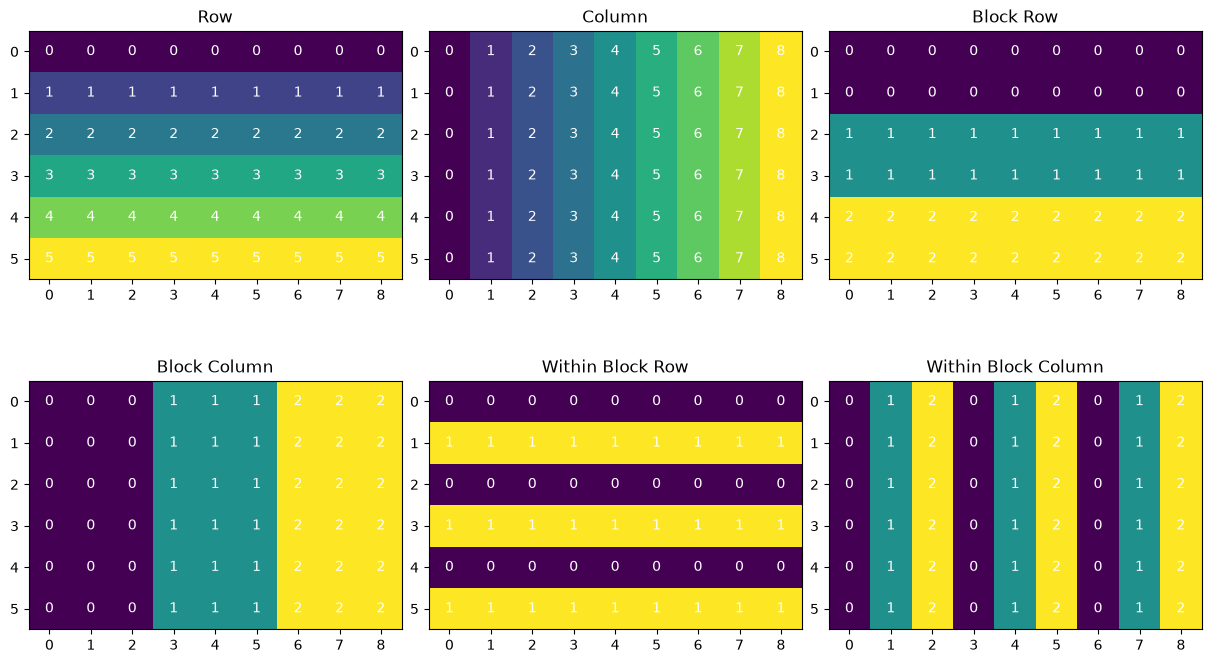

In [2]:
from featuregraph_research import coordinate_arrays, plot_array_axes

axes = coordinate_arrays((6, 9), block_shape=(2, 3))
figure, panels = plot_array_axes(axes)

In [3]:
held_out_index = 0
pair_indices = np.arange(len(training_pairs))
training_mask = pair_indices != held_out_index

In [4]:
pair_indices

array([0, 1])

In [5]:
training_mask

array([False,  True])

In [6]:
retained_indices = pair_indices[training_mask]
held_out_indices = pair_indices[~training_mask]

In [7]:
retained_indices

array([1])

In [8]:
held_out_indices

array([0])

In [9]:
retained_pairs = [
    training_pairs[index]
    for index in retained_indices
]

held_out_pair = training_pairs[held_out_indices[0]]

In [10]:
len(retained_pairs)
held_out_pair.keys()

dict_keys(['grid', 'output'])

In [11]:
from featuregraph_research.utils._arc_agi import state_training_cycle

grid_shape = retained_pairs[0]["grid"].shape
output_shape = retained_pairs[0]["output"].shape

block_layout_shape = (
    output_shape[0] // grid_shape[0],
    output_shape[1] // grid_shape[1],
)

grid_shape, output_shape, block_layout_shape

((2, 2), (6, 6), (3, 3))

In [12]:
from featuregraph_research.utils._arc_agi import training_cycle

instruction_layout = training_cycle(retained_pairs)
instruction_layout

ValueError: Multiple operators remain after all training pairs for block (1, 0): ['flip_horizontal', 'rotate_270']

In [ ]:
held_out_index = 1
training_mask = pair_indices != held_out_index

retained_indices = pair_indices[training_mask]
held_out_indices = pair_indices[~training_mask]

retained_pairs = [
    training_pairs[index]
    for index in retained_indices
]

held_out_pair = training_pairs[held_out_indices[0]]

instruction_layout = training_cycle(retained_pairs)
instruction_layout

array([['copy', 'copy', 'copy'],
       ['flip_horizontal', 'flip_horizontal', 'flip_horizontal'],
       ['copy', 'copy', 'copy']], dtype=object)

In [ ]:
from featuregraph_research.utils._arc_agi import test_cycle

held_out_prediction = test_cycle(
    held_out_pair["grid"],
    instruction_layout,
)

held_out_exact = np.array_equal(
    held_out_prediction,
    held_out_pair["output"],
)

held_out_exact

True

In [ ]:
from itertools import combinations

import numpy as np

from featuregraph_research.utils._arc_agi import training_cycle, test_cycle


def validate_fixed_layout_subsets(training_pairs):
    number_of_pairs = len(training_pairs)
    pair_indices = np.arange(number_of_pairs)
    fold_results = []

    # Proper, nonempty subsets only.
    for retained_count in range(1, number_of_pairs):
        for retained_tuple in combinations(
            pair_indices,
            retained_count,
        ):
            retained_indices = np.array(retained_tuple)
            held_out_indices = pair_indices[
                ~np.isin(pair_indices, retained_indices)
            ]

            retained_pairs = [
                training_pairs[index]
                for index in retained_indices
            ]

            try:
                instruction_layout = training_cycle(
                    retained_pairs
                )
            except ValueError as error:
                fold_results.append({
                    "retained_indices": retained_indices.tolist(),
                    "held_out_indices": held_out_indices.tolist(),
                    "outcome": "ambiguous",
                    "exact": None,
                    "reason": str(error),
                })
                continue

            held_out_matches = []

            for index in held_out_indices:
                held_out_pair = training_pairs[index]

                prediction = test_cycle(
                    held_out_pair["grid"],
                    instruction_layout,
                )

                held_out_matches.append(
                    np.array_equal(
                        prediction,
                        held_out_pair["output"],
                    )
                )

            all_exact = all(held_out_matches)

            fold_results.append({
                "retained_indices": retained_indices.tolist(),
                "held_out_indices": held_out_indices.tolist(),
                "outcome": (
                    "exact" if all_exact else "incorrect"
                ),
                "exact": all_exact,
                "reason": None,
            })

    return fold_results

In [ ]:
fold_results = validate_fixed_layout_subsets(
    training_pairs
)

fold_results

[{'retained_indices': [0],
  'held_out_indices': [1],
  'outcome': 'exact',
  'exact': True,
  'reason': None},
 {'retained_indices': [1],
  'held_out_indices': [0],
  'outcome': 'ambiguous',
  'exact': None,
  'reason': "Multiple operators remain after all training pairs for block (1, 0): ['flip_horizontal', 'rotate_270']"}]

In [ ]:
outcomes = np.array([
    result["outcome"]
    for result in fold_results
])

task_summary = {
    "task_id": "00576224",
    "structural_match": True,
    "training_reconstruction": True,
    "folds_total": len(fold_results),
    "folds_exact": np.sum(outcomes == "exact"),
    "folds_ambiguous": np.sum(outcomes == "ambiguous"),
    "folds_incorrect": np.sum(outcomes == "incorrect"),
    "all_identifiable_folds_exact": np.all(
        outcomes != "incorrect"
    ),
    "exact_test": True,
}

task_summary

{'task_id': '00576224',
 'structural_match': True,
 'training_reconstruction': True,
 'folds_total': 2,
 'folds_exact': np.int64(1),
 'folds_ambiguous': np.int64(1),
 'folds_incorrect': np.int64(0),
 'all_identifiable_folds_exact': np.True_,
 'exact_test': True}